In [ ]:
def read_csv(path):
    x1s = []
    x2s = []
    ys = []
    f = open(path, "r")
    first = True
    for line in f:
        line = line.strip()
        if line == "":
            continue
        if first:
            first = False
            continue
        parts = line.split(",")
        x2 = float(parts[0])
        x1 = float(parts[1])
        y  = float(parts[2])
        x1s.append(x1)
        x2s.append(x2)
        ys.append(y)
    f.close()
    return x1s, x2s, ys

x1s, x2s, ys = read_csv("../Dataset/loan2.csv")
N = len(x1s)
data = list(zip(x1s, x2s, ys))

print("Loaded", N, "points")
for i in range(N):
    print("  x1 =", x1s[i], ", x2 =", x2s[i], ", y =", ys[i])

Loaded 19 points
  x1 = 4.0 , x2 = 3.0 , y = 1.0
  x1 = 4.0 , x2 = 2.5 , y = 1.0
  x1 = 4.0 , x2 = 1.0 , y = 0.0
  x1 = 5.0 , x2 = 2.5 , y = 1.0
  x1 = 5.0 , x2 = 2.0 , y = 1.0
  x1 = 5.0 , x2 = 1.5 , y = 0.0
  x1 = 5.0 , x2 = 0.5 , y = 0.0
  x1 = 6.0 , x2 = 1.75 , y = 1.0
  x1 = 6.0 , x2 = 0.25 , y = 0.0
  x1 = 7.0 , x2 = 1.0 , y = 1.0
  x1 = 7.0 , x2 = 0.25 , y = 0.0
  x1 = 7.0 , x2 = 0.2 , y = 0.0
  x1 = 7.0 , x2 = 0.15 , y = 0.0
  x1 = 8.0 , x2 = 2.0 , y = 1.0
  x1 = 8.0 , x2 = 1.0 , y = 0.0
  x1 = 8.0 , x2 = 0.15 , y = 0.0
  x1 = 8.0 , x2 = 0.1 , y = 0.0
  x1 = 9.0 , x2 = 0.5 , y = 1.0
  x1 = 10.0 , x2 = 1.0 , y = 1.0


In [33]:
import math

def sigmoid(z):
    return 1 / (1 + math.exp(-z))

def predict(x1, x2, w0, w1, w2):
    z = w1 * x1 + w2 * x2 + w0
    return sigmoid(z)

def loss(w0, w1, w2):
    s = 0.0
    for i in range(N):
        y_hat = predict(x1s[i], x2s[i], w0, w1, w2)
        s = s - (ys[i] * math.log(y_hat) + (1 - ys[i]) * math.log(1 - y_hat))
    return s / N

In [34]:
def train(w0, w1, w2, r, iters):
    for it in range(iters):
        for i in range(N):
            y_hat = predict(x1s[i], x2s[i], w0, w1, w2)
            e = y_hat - ys[i]
            w0 = w0 - r * e
            w1 = w1 - r * x1s[i] * e
            w2 = w2 - r * x2s[i] * e
        if (it + 1) % 100 == 0 or it == 0:
            print(f"Iteration {it+1}: w0 = {w0:.4f}, w1 = {w1:.4f}, w2 = {w2:.4f}, J = {loss(w0, w1, w2):.4f}")
    return w0, w1, w2

w0, w1, w2 = train(0.0, 1.0, 2.0, 0.05, 1000)

print()
print("Final weights:")
print("  w0 =", w0)
print("  w1 =", w1)
print("  w2 =", w2)


Iteration 1: w0 = -0.2021, w1 = 0.0811, w2 = 1.8676, J = 0.8514
Iteration 100: w0 = -3.9951, w1 = 0.4903, w2 = 2.0029, J = 0.5007
Iteration 200: w0 = -6.5077, w1 = 0.7460, w2 = 2.4038, J = 0.3728
Iteration 300: w0 = -8.3198, w1 = 0.9323, w2 = 2.7433, J = 0.3178
Iteration 400: w0 = -9.7412, w1 = 1.0807, w2 = 3.0276, J = 0.2895
Iteration 500: w0 = -10.9171, w1 = 1.2053, w2 = 3.2703, J = 0.2730
Iteration 600: w0 = -11.9229, w1 = 1.3129, w2 = 3.4823, J = 0.2625
Iteration 700: w0 = -12.8016, w1 = 1.4072, w2 = 3.6712, J = 0.2553
Iteration 800: w0 = -13.5804, w1 = 1.4907, w2 = 3.8420, J = 0.2501
Iteration 900: w0 = -14.2775, w1 = 1.5651, w2 = 3.9981, J = 0.2460
Iteration 1000: w0 = -14.9061, w1 = 1.6318, w2 = 4.1416, J = 0.2428

Final weights:
  w0 = -14.906107372028133
  w1 = 1.631770337598238
  w2 = 4.141624706670592


In [35]:
threshold = 0.5
correct = 0

print("Predictions on training data (threshold =", threshold, ")")
for i in range(N):
    p = predict(x1s[i], x2s[i], w0, w1, w2)
    if p > threshold:
        pred_label = 1
    else:
        pred_label = 0
    actual = int(ys[i])
    if pred_label == actual:
        correct = correct + 1
    print(f"  x1={x1s[i]:.2f}, x2={x2s[i]:.2f}, prob={p:.4f} -> pred={pred_label}, actual={actual}")

print()
print("Accuracy:", correct, "/", N, "=", round(correct/N*100, 1), "%")

Predictions on training data (threshold = 0.5 )
  x1=4.00, x2=3.00, prob=0.9828 -> pred=1, actual=1
  x1=4.00, x2=2.50, prob=0.8782 -> pred=1, actual=1
  x1=4.00, x2=1.00, prob=0.0142 -> pred=0, actual=0
  x1=5.00, x2=2.50, prob=0.9736 -> pred=1, actual=1
  x1=5.00, x2=2.00, prob=0.8229 -> pred=1, actual=1
  x1=5.00, x2=1.50, prob=0.3694 -> pred=0, actual=0
  x1=5.00, x2=0.50, prob=0.0092 -> pred=0, actual=0
  x1=6.00, x2=1.75, prob=0.8940 -> pred=1, actual=1
  x1=6.00, x2=0.25, prob=0.0166 -> pred=0, actual=0
  x1=7.00, x2=1.00, prob=0.6588 -> pred=1, actual=1
  x1=7.00, x2=0.25, prob=0.0796 -> pred=0, actual=0
  x1=7.00, x2=0.20, prob=0.0657 -> pred=0, actual=0
  x1=7.00, x2=0.15, prob=0.0540 -> pred=0, actual=0
  x1=8.00, x2=2.00, prob=0.9984 -> pred=1, actual=1
  x1=8.00, x2=1.00, prob=0.9080 -> pred=1, actual=0
  x1=8.00, x2=0.15, prob=0.2261 -> pred=0, actual=0
  x1=8.00, x2=0.10, prob=0.1919 -> pred=0, actual=0
  x1=9.00, x2=0.50, prob=0.8642 -> pred=1, actual=1
  x1=10.00, x2=1

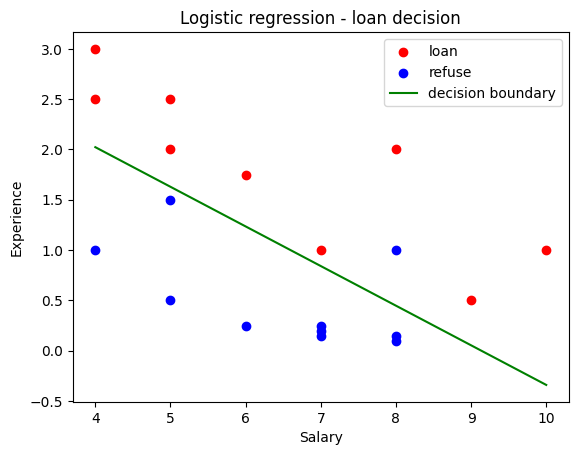

In [ ]:
import matplotlib.pyplot as plt

# Split data by class
loan_x1 = [x1 for x1, x2, y in data if y == 1]
loan_x2 = [x2 for x1, x2, y in data if y == 1]
refuse_x1 = [x1 for x1, x2, y in data if y == 0]
refuse_x2 = [x2 for x1, x2, y in data if y == 0]

x1_line = [min(x1s), max(x1s)]
x2_line = [-(w0 + w1*x1) / w2 for x1 in x1_line]

plt.scatter(loan_x1, loan_x2, color="red", label="loan")
plt.scatter(refuse_x1, refuse_x2, color="blue", label="refuse")
plt.plot(x1_line, x2_line, color="green", label="decision boundary")
plt.xlabel("Salary")
plt.ylabel("Experience")
plt.title("Logistic regression - loan decision")
plt.legend()
plt.savefig("logistic_regression.png")
plt.show()
